In [9]:
from burau_package.classes.generators import Generators
from burau_package.classes.laurent_matrix import LaurentMatrix
from burau_package.scripts.free_scripts import calculate_products
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p
from burau_package.RL.env import BurauEnv
from stable_baselines3 import DQN,PPO,A2C
from stable_baselines3.common.callbacks import ProgressBarCallback


In [10]:
from burau_package.classes.generators import Generators
from burau_package.classes.laurent_matrix import LaurentMatrix

Here are generators A,a,B,b:

In [5]:
gens = Generators() #creates generators object
A = gens.A 
a = gens.a
B = gens.B
b = gens.b
print(type(A))
print(A)
print(A*a)
print(A**10)
print(A*B*B*a*b)

<class 'burau_package.classes.laurent_matrix.LaurentMatrix'>
[
 [0, 0, -1.0x^-1],
 [0, -1.0x^1, 1.0x^1 + -1.0x^-1],
 [-1.0, 0, 1.0 + -1.0x^-1]
]
[
 [1.0, 0, 0],
 [0, 1.0, 0],
 [0, 0, 1.0]
]
[
 [1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 0, -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-10],
 [-1.0x^9 + 1.0x^8 + -1.0x^7 + 1.0x^6 + -1.0x^5 + 1.0x^4 + -1.0x^3 + 1.0x^2 + -1.0x^1 + 1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 1.0x^10, -1.0x^10 + 1.0x^9 + -1.0x^8 + 1.0x^7 + -1.0x^6 + 1.0x^5 + -1.0x^4 + 1.0x^3 + -1.0x^2 + 1.0x^1 + -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-10],
 [-1.0 + 1.0x^-1 + -1.0x^-2 + 1.0x^-3 + -1.0x^-4 + 1.0x^-5 + -1.0x^-6 + 1.0x^-7 + -1.0x^-8 + 1.0x^-9, 0, 1.0 + -1.0x^-1 + 1.0x^-2 + -1.0x^-3 + 1.0x^-4 + -1.0x^-5 + 1.0x^-6 + -1.0x^-7 + 1.0x^-8 + -1.0x^-9 + 1.0x^-

We can make their coordinates modulo k the following way:

In [6]:
gens = Generators(mod= 2)
Amod2 = gens.A
print(Amod2)

Matrix (mod 2):
[
 [0 (mod 2), 0 (mod 2), 1x^-1 (mod 2)],
 [0 (mod 2), 1x^1 (mod 2), 1x^1 + 1x^-1 (mod 2)],
 [1 (mod 2), 0 (mod 2), 1 + 1x^-1 (mod 2)]
]


Algorithm that find identity mod 2:

In [6]:
from burau_package.scripts.free_scripts import calculate_products
mod = 2
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
k = 4
init_dict = calculate_products(base_dict.copy(), max_length=k) #calculate all words up to length k
#Some examples
print(init_dict["AABab"])
print(len(init_dict))

100%|██████████| 4/4 [00:00<00:00,  9.83it/s]

Matrix (mod 2):
[
 [1x^2 + 1x^1 + 1x^-1 + 1x^-2 (mod 2), 1x^2 + 1x^1 + 1x^-1 + 1x^-2 (mod 2), 1x^-3 (mod 2)],
 [1x^5 + 1x^4 + 1x^-1 + 1x^-2 (mod 2), 1x^5 + 1x^4 + 1x^-2 (mod 2), 1x^-1 + 1x^-3 (mod 2)],
 [1x^3 + 1x^2 + 1 + 1x^-1 + 1x^-2 (mod 2), 1x^3 + 1x^2 + 1 + 1x^-1 (mod 2), 1x^-2 + 1x^-3 (mod 2)]
]
484


Now, throw away all words of length less than max_length

In [14]:
init_dict= {key: value for key, value in init_dict.items() if len(key) == k} 

How, run selection process for some number of turns:

In [1]:
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p

In [10]:
tiered_dict = init_dict.copy()
for i in range(28):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 20000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        #repeating

5 (3, 0, [])
6 (3, 0, [])
7 (3, 0, [])
8 (4, 0, [])
9 (4, 0, [])
10 (4, 0, [])
11 (4, 0, [])
12 (4, 0, [])
13 (4, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (4, 0, [])
17 (3, 0, [])
18 (4, 0, [])
19 (4, 0, [])
20 (4, 0, [])
21 (4, 0, [])
22 (4, 0, [])
23 (3, 0, [])
24 (4, 0, [])
25 (3, 0, [])
26 (4, 0, [])
27 (3, 0, [])
28 (3, 0, [])
29 (2, 0, [])
30 (2, 0, [])
31 (1, 0, [])
32 (0, 4, ['BAAABAbbAbbbbbAbABBBABaaBaaaaaBa', 'babbbbbabbaBaaaBABAAAAABAABaBBBa', 'AbAAAAAbAAbabbbaBaBBBBBaBBabaaab', 'BaBBBBBaBBabaaabAbAAAAAbAAbabbba'])


In [19]:
tiered_dict = init_dict.copy()
for i in range(31):
        #taking best m matrices (in principle there are different ways, but here it is enough)
        m = 10
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        #extending tiered array
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        #printing info
        """
        "current length" "(minimal value of invariant, number of found indentities, dictionary of indentities)"
        """
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))
        #repeating

2 (2, 0, [])
3 (2, 0, [])
4 (3, 0, [])
5 (3, 0, [])
6 (3, 0, [])
7 (4, 0, [])
8 (4, 0, [])
9 (4, 0, [])
10 (4, 0, [])
11 (4, 0, [])
12 (5, 0, [])
13 (5, 0, [])
14 (5, 0, [])
15 (5, 0, [])
16 (5, 0, [])
17 (5, 0, [])
18 (5, 0, [])
19 (5, 0, [])
20 (6, 0, [])
21 (5, 0, [])
22 (5, 0, [])
23 (6, 0, [])
24 (6, 0, [])
25 (6, 0, [])
26 (5, 0, [])
27 (5, 0, [])
28 (4, 0, [])
29 (4, 0, [])
30 (5, 0, [])
31 (5, 0, [])
32 (5, 0, [])


So m = 20000 enough to find word of length 32 (m = 10000 not enough), but to find word of length 34 even m = 10 is enough (even though not in every run)

In [16]:
tiered_dict = init_dict.copy()
for i in range(25):
        m = 10
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))


10 (4, 0, [])
11 (4, 0, [])
12 (5, 0, [])
13 (5, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (4, 0, [])
17 (3, 0, [])
18 (4, 0, [])
19 (5, 0, [])
20 (5, 0, [])
21 (5, 0, [])
22 (4, 0, [])
23 (4, 0, [])
24 (4, 0, [])
25 (4, 0, [])
26 (4, 0, [])
27 (3, 0, [])
28 (4, 0, [])
29 (4, 0, [])
30 (3, 0, [])
31 (2, 0, [])
32 (2, 0, [])
33 (1, 0, [])
34 (0, 1, ['AbAAAbAAbAAbAAAbAABAAABAABAABAAABA'])


Now, let's do the same modulo 3

In [17]:
mod = 3
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
k = 9
init_dict = calculate_products(base_dict.copy(), max_length=k) 
init_dict = {key: value for key, value in init_dict.items() if len(key) == k} 

100%|██████████| 9/9 [00:19<00:00,  2.15s/it]


In [19]:

tiered_dict = init_dict.copy()
for i in range(350):
        m = 10000
        tiered_dict = tiered_sampling(tiered_dict,min_num=m,max_num=m) 
        tiered_dict = extend_in_all_ways_p(base_dict,tiered_dict,1)
        print(len(next(iter(tiered_dict))),min_invariant_in_array(tiered_dict,largest_power_range))



10 (4, 0, [])
11 (4, 0, [])
12 (4, 0, [])
13 (4, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (5, 0, [])
17 (4, 0, [])
18 (5, 0, [])
19 (5, 0, [])
20 (5, 0, [])
21 (5, 0, [])
22 (5, 0, [])
23 (5, 0, [])
24 (5, 0, [])
25 (5, 0, [])
26 (5, 0, [])
27 (5, 0, [])
28 (5, 0, [])
29 (5, 0, [])
30 (5, 0, [])
31 (5, 0, [])
32 (6, 0, [])
33 (6, 0, [])
34 (5, 0, [])
35 (6, 0, [])
36 (6, 0, [])
37 (6, 0, [])
38 (6, 0, [])
39 (6, 0, [])
40 (6, 0, [])
41 (5, 0, [])
42 (6, 0, [])
43 (6, 0, [])
44 (6, 0, [])
45 (6, 0, [])
46 (6, 0, [])
47 (6, 0, [])
48 (6, 0, [])
49 (6, 0, [])
50 (6, 0, [])
51 (6, 0, [])
52 (6, 0, [])
53 (6, 0, [])
54 (6, 0, [])
55 (6, 0, [])
56 (6, 0, [])
57 (5, 0, [])
58 (6, 0, [])
59 (6, 0, [])
60 (6, 0, [])
61 (6, 0, [])
62 (6, 0, [])
63 (6, 0, [])
64 (5, 0, [])
65 (6, 0, [])
66 (6, 0, [])
67 (7, 0, [])
68 (7, 0, [])
69 (6, 0, [])
70 (6, 0, [])
71 (5, 0, [])
72 (6, 0, [])
73 (7, 0, [])
74 (6, 0, [])
75 (6, 0, [])
76 (7, 0, [])
77 (7, 0, [])
78 (7, 0, [])
79 (7, 0, [])
80 (7, 0, [])
81 (7,

It found word of length 338

Now idea is to apply RL to find a words for mod = 5, or even over \mathbb{Z}.

The environment is the following:

In [ ]:
from burau_package.RL.env import BurauEnv

In [4]:


#We have to specify mod and maximum length
mod = 2
max_len = 32
env = BurauEnv(mod = mod,obs = max_len)
env.render()
#Action space is 0,1,2,3 which is applying correspondning letters
#Note than what is stored in step is +1 of what is the real action
print(env.step(0))
env.render()
# The reward is +1 if degree is decreased, -1 if increased, -100 if made inverse
print(env.step(1))
env.render()
print(env.step(2))
env.render()
print(env._get_action_mask())



[Turn 0] word = (empty)
([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], -1, False, False, {})
[Turn 1] word = A
([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2], -1, False, False, {})
[Turn 2] word = AB
([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3], -100, True, False, {})
[Turn 3] word = ABb
[1 0 1 1]


Let's now try to run basic DQN from SB3

In [2]:
from stable_baselines3 import DQN,PPO,A2C
from stable_baselines3.common.callbacks import ProgressBarCallback

In [5]:
env = BurauEnv(mod=2,obs=34)
model = DQN("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=100000,progress_bar=True)


Output()

In [12]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = bababaabaababaababababaabababababa
10


But if we will run with too much episodes it will be worse

In [13]:
env = BurauEnv(mod=2,obs=34)
model = DQN("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=1000000,progress_bar=True)


Output()

In [14]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = aaaaaaaaaaaaaaaaaaaaabaaaaaaaababa
24


Let's try to optimize hyperparameters using optuna

In [ ]:
import optuna
from stable_baselines3.common.evaluation import evaluate_policy

In [ ]:
def objective(trial):
    env = BurauEnv(mod=2, obs=34)

    params = dict(
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 3e-3, log=True),
        buffer_size=trial.suggest_int("buffer_size", 10_000, 300_000, step=1000),
        learning_starts=trial.suggest_int("learning_starts", 0, 20_000, step=1000),
        batch_size=trial.suggest_categorical("batch_size", [32,64, 128, 256, 512, 1024]),
        gamma=trial.suggest_float("gamma", 0.95, 0.9999),
        target_update_interval=trial.suggest_int("target_update_interval", 1_000, 20_000, step=1000),
        train_freq=trial.suggest_categorical("train_freq", [1, 4, 8]),  # steps
        exploration_fraction=trial.suggest_float("exploration_fraction", 0.05, 0.4),
        exploration_initial_eps=trial.suggest_float("exploration_initial_eps", 0.8, 1.0),
        exploration_final_eps=trial.suggest_float("exploration_final_eps", 0.01, 0.3),
        verbose=0,
        
    )
    total_timesteps=trial.suggest_int("total_timesteps", 50_000, 200000, step=10000)
    model = DQN("MlpPolicy", env, **params)
    model.learn(total_timesteps=total_timesteps)  # keep small for speed

    eval_env = BurauEnv(mod=2, obs=34)
    mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True)
    eval_env.close()
    env.close()
    return mean_reward  # Optuna will MAXIMIZE this
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500, n_jobs=8)  # change n_trials as you like

print("Best mean reward:", study.best_value)
print("Best params:", study.best_params)



[I 2025-09-14 10:07:12,816] A new study created in memory with name: no-name-96cec471-c1d3-4e2d-907a-3fca519838cd
/opt/homebrew/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
[I 2025-09-14 11:46:09,599] Trial 4 finished with value: -19.0 and parameters: {'learning_rate': 1.3333148490445958e-05, 'buffer_size': 43000, 'learning_starts': 15000, 'batch_size': 1024, 'gamma': 0.9856823341996652, 'target_update_interval': 13000, 'train_freq': 4, 'exploration_fraction': 0.11108845646751159, 'exploration_initial_eps': 0.8157804784309817, 'exploration_final_eps': 0.2726623016301785, 'total_timesteps': 110000}. Best is trial 4 with value: -19.0.
[I 2025-09-14 13:59:22,121] Trial 6 finished with value: -20.0 an

Best mean reward: -6.0
Best params: {'learning_rate': 2.233990531449866e-05, 'buffer_size': 298000, 'learning_starts': 2000, 'batch_size': 128, 'gamma': 0.9718909936789241, 'target_update_interval': 12000, 'train_freq': 4, 'exploration_fraction': 0.1258984654057439, 'exploration_initial_eps': 0.8667922055454196, 'exploration_final_eps': 0.07943696883310046, 'total_timesteps': 120000}


In [33]:
best_params = {'learning_rate': 2.233990531449866e-05, 'buffer_size': 298000, 'learning_starts': 2000, 'batch_size': 128, 'gamma': 0.9718909936789241, 'target_update_interval': 12000, 'train_freq': 4, 'exploration_fraction': 0.1258984654057439, 'exploration_initial_eps': 0.8667922055454196, 'exploration_final_eps': 0.07943696883310046}
env = BurauEnv(mod=2, obs=34)
model_params = dict(256,256)
model = DQN("MlpPolicy", env, **best_params)
model.learn(total_timesteps=1000000,progress_bar=True)


TypeError: dict expected at most 1 argument, got 2

In [35]:
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

[Turn 34] word = aBaababaababaabababaabababaaaabaBA
13


In [7]:
from burau_package.RL.dqn import dqn
from burau_package.RL.env import BurauEnv
env = BurauEnv(mod=2,obs=34)
dqn(modulo=2,max_steps=34)

  2%|▏         | 1005/50000 [00:20<16:36, 49.19it/s]

[Episode   1000] AvgReward=-29.070, AvgLoss=20.49533, FinalWord=[4, 2, 2, 1, 2, 4, 2, 1, 1, 1, 2, 4, 3, 1, 3, 4, 3, 1, 1, 2, 1, 2, 2, 1, 3, 3, 3, 4, 3, 3, 3, 1, 3, 3], MaxPowerRange=24, Wins=0%, Loses=0%, Timeouts=0%


  4%|▍         | 2006/50000 [00:41<17:32, 45.59it/s]

[Episode   2000] AvgReward=-23.820, AvgLoss=5.49357, FinalWord=[2, 4, 4, 2, 4, 4, 3, 4, 4, 4, 4, 2, 1, 1, 3, 1, 2, 1, 1, 3, 4, 2, 2, 1, 3, 3, 4, 3, 1, 3, 3, 1, 1, 3], MaxPowerRange=28, Wins=0%, Loses=0%, Timeouts=0%


  6%|▌         | 3005/50000 [01:02<16:02, 48.83it/s]

...

[Episode  48000] AvgReward=-11.870, AvgLoss=0.06479, FinalWord=[4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4, 3], MaxPowerRange=8, Wins=0%, Loses=0%, Timeouts=0%


 98%|█████████▊| 49007/50000 [17:30<00:21, 46.48it/s]

[Episode  49000] AvgReward=-5.420, AvgLoss=0.06345, FinalWord=[1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1], MaxPowerRange=4, Wins=0%, Loses=0%, Timeouts=0%


100%|██████████| 50000/50000 [17:52<00:00, 46.62it/s]


[Episode  50000] AvgReward=-1.210, AvgLoss=0.06717, FinalWord=[1, 3, 1, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1], MaxPowerRange=0, Wins=0%, Loses=0%, Timeouts=0%


In [ ]:
from burau_package.RL.dqn import dqn
from burau_package.RL.env import BurauEnv
env = BurauEnv(mod=2,obs=32)
dqn(modulo=2,max_steps=32, num_episodes=200000)

  1%|          | 1009/200000 [00:17<53:02, 62.53it/s] 

[Turn 32] word = aBaaBBBBBAbbaababbABBABaaabbbaba
[Episode   1000] AvgReward=-3.010, AvgLoss=40.00930, FinalWord=[4, 2, 4, 4, 2, 2, 2, 2, 2, 1, 3, 3, 4, 4, 3, 4, 3, 3, 1, 2, 2, 1, 2, 4, 4, 4, 3, 3, 3, 4, 3, 4], MaxPowerRange=23, Wins=0%, Loses=0%, Timeouts=0%


  1%|          | 2006/200000 [00:35<1:01:16, 53.86it/s]

[Turn 32] word = BabABAbbAbbAbaBBABAABAAAbbbABAbb
[Episode   2000] AvgReward=8.940, AvgLoss=20.70007, FinalWord=[2, 4, 3, 1, 2, 1, 3, 3, 1, 3, 3, 1, 3, 4, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 3, 3, 3, 1, 2, 1, 3, 3], MaxPowerRange=22, Wins=0%, Loses=0%, Timeouts=0%


  2%|▏         | 3008/200000 [00:53<1:01:26, 53.43it/s]

...

[Turn 32] word = bAbAAbAbAAbAbAAbAbAAbAAbAbAAbAbA
[Episode 198000] AvgReward=26.150, AvgLoss=0.07553, FinalWord=[3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


100%|█████████▉| 199004/200000 [2:01:43<00:25, 38.36it/s]

[Turn 32] word = bAAbAbAAbAbAAbAbAAbAAbAbAAbAbAAb
[Episode 199000] AvgReward=26.210, AvgLoss=0.12194, FinalWord=[3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


100%|██████████| 200000/200000 [2:02:09<00:00, 27.29it/s]


[Turn 32] word = aBAbAAbAbAAbAbAAbAbAAbAAbAbABABB
[Episode 200000] AvgReward=25.690, AvgLoss=0.09367, FinalWord=[4, 2, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 3, 1, 1, 3, 1, 3, 1, 2, 1, 2, 2], MaxPowerRange=7, Wins=0%, Loses=0%, Timeouts=0%


Output()

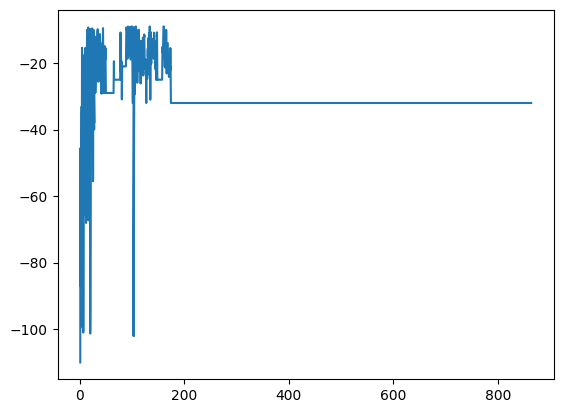

In [2]:
from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results
import matplotlib.pyplot as plt
import os
import pandas as pd, glob, matplotlib.pyplot as plt

log_dir = "./logs_a2c"
os.makedirs(log_dir, exist_ok=True)

# 1) wrap env to log episode rewards/timesteps
env = Monitor(BurauEnv(mod=2, obs=32), log_dir)

# 2) train as usual
model = A2C("MlpPolicy", env, verbose=0, learning_rate=0.01, ent_coef=0.1)
model.learn(total_timesteps=2000000,progress_bar=True)

df = pd.concat([pd.read_csv(f, skiprows=1) for f in glob.glob(f"{log_dir}/*monitor*.csv")]).sort_values("t")
df["r_mean_50"] = df["r"].rolling(50, min_periods=1).mean()
plt.plot(df["t"], df["r_mean_50"]); plt.show()

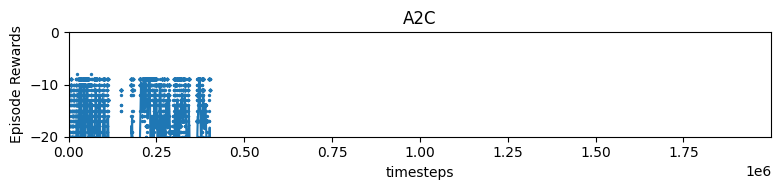

In [5]:
plot_results([log_dir], num_timesteps=None, x_axis="timesteps", task_name="A2C")
ax = plt.gca()
ax.set_ylim(-20, 0)
plt.show()

In [ ]:
env = BurauEnv(mod=2,obs=32)
obs, info = env.reset()
done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
env.render() #print word
print(largest_power_range(env.matrix)) #print it's degree (for identity should be zero)

In [1]:
from burau_package.RL.env import BurauEnv
from burau_package.RL.MCTS import mcts_search
from burau_package.scripts.free_scripts import tiered_sampling, min_invariant_in_array, largest_power_range, extend_in_all_ways_p

In [4]:
max_steps = 32
env = BurauEnv(mod=2,obs=max_steps, reward_fun="old")
total_reward = 0
for _ in range(max_steps):
    action = mcts_search(env, reward=total_reward,iterations = 10)
    _, reward, _, _, _ = env.step(action)
    total_reward += reward
    env.render()
print(largest_power_range(env.matrix))


[Turn 1] word = a
[Turn 2] word = aB
[Turn 3] word = aBB
[Turn 4] word = aBBB
[Turn 5] word = aBBBB
[Turn 6] word = aBBBBB
[Turn 7] word = aBBBBBa
[Turn 8] word = aBBBBBaB
[Turn 9] word = aBBBBBaBB
[Turn 10] word = aBBBBBaBBa
[Turn 11] word = aBBBBBaBBab
[Turn 12] word = aBBBBBaBBaba
[Turn 13] word = aBBBBBaBBabaa
[Turn 14] word = aBBBBBaBBabaaa
[Turn 15] word = aBBBBBaBBabaaab
[Turn 16] word = aBBBBBaBBabaaabA
[Turn 17] word = aBBBBBaBBabaaabAb
[Turn 18] word = aBBBBBaBBabaaabAbA
[Turn 19] word = aBBBBBaBBabaaabAbAA
[Turn 20] word = aBBBBBaBBabaaabAbAAA
[Turn 21] word = aBBBBBaBBabaaabAbAAAA
[Turn 22] word = aBBBBBaBBabaaabAbAAAAA
[Turn 23] word = aBBBBBaBBabaaabAbAAAAAb
[Turn 24] word = aBBBBBaBBabaaabAbAAAAAbA
[Turn 25] word = aBBBBBaBBabaaabAbAAAAAbAA
[Turn 26] word = aBBBBBaBBabaaabAbAAAAAbAAb
[Turn 27] word = aBBBBBaBBabaaabAbAAAAAbAAba
[Turn 28] word = aBBBBBaBBabaaabAbAAAAAbAAbab
[Turn 29] word = aBBBBBaBBabaaabAbAAAAAbAAbabb
[Turn 30] word = aBBBBBaBBabaaabAbAAAAAbAAbabbb
[Tur

In [ ]:
import optuna
def objective(trial):
    c = trial.suggest_float("uct_c", 0.1, 3.0, log=True),     
    max_steps = 32

    avg_reward = 0
    for _ in range(10):
        env = BurauEnv(mod=2,obs=max_steps, reward_fun="old")
        total_reward = 0
        for _ in range(max_steps):
            action = mcts_search(env, reward=total_reward,iterations = 10, c = float(c[0]))
            _, reward, _, _, _ = env.step(action)
            total_reward += reward
        avg_reward += largest_power_range(env.matrix)
    avg_reward = avg_reward/10
    return avg_reward
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, n_jobs=8)  # change n_trials as you like

print("Best mean reward:", study.best_value)
print("Best params:", study.best_params)



[I 2025-10-05 16:07:05,565] Trial 89 finished with value: 14.2 and parameters: {'uct_c': 2.3104605367112683}. Best is trial 63 with value: 13.5.


In [5]:
def replace_word(word, replace_dict):
    return ''.join(replace_dict.get(ch, ch) for ch in word)
        

In [3]:
import random
mod = None
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
def get_degree_of_word(word,dict = base_dict):
    matrix = word_to_matrix(dict,word=word)
    return matrix, largest_power_range(matrix)

def random_reduced_word(max_len: int) -> str:
    letters = ['A', 'B', 'a', 'b']
    inverses = {'A': 'a', 'a': 'A', 'B': 'b', 'b': 'B'}

    word = []
    for _ in range(random.randint(1, max_len)):
        choices = [l for l in letters if not word or l != inverses[word[-1]]]
        word.append(random.choice(choices))
    return ''.join(word)
    

In [72]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(100):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 50)
        
        mat1 , deg1 = get_degree_of_word(word)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        print(word)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0
aBaBAbAb
bbbAbbAABBBBaBabAbaabbaBaBAAbabaaBBBBBAAABaaBaBAB
bAbbABBaaBaaBAbAAbabABaabbabAbbb
aaabbbbbbaBBBAABAbABBAbbab
abaBBBABBBABABAbbaabAbabAAABAbbAb
Bab
AAbAABABabABAAbABabbabAbabba
abABBBABaBAAAbbAbaaabbbbAba
ABBaBabABAbaaaBabaaaBBaBAbAAAbAAbaabbaabaa
AABAbaaaBABAAABaBabb
AABaabaabbbbbAABAAb
bbabbaBABaaabbABBaB
BaaabaababaBABBAABBaBabaaBBABaaabAbAbbAA
abaBabbbbaaabABABBabbbAAbAbababbAbaabaaaaabABBABBB
ababbaaBAABABAbABaabaBBaaaabaBBBBABABabbbAB
BBabbaBaBBBBAbaabaBAAAbaabbaaBBBaaBaa
AABBBAAAbaBABBAbAAABAABBaaabAbabAAbb
ABBaaBBBABAAbaBBAbABBabAbaaBAbbABBAbABBBAbAA
aaBBBAAAbaaaBBAb
AAABabaBAbAABAbabaaBaaaab
ABabaa
bbaabaBABaaa
abbAAABBBaabaBABBAAABBBaaabaBAB
ABBAB
A
aBAAbaBBBaabaBAAbbabbAAbbAbbbaBa
bbaaBAbAbAba
abaaaaaaababaabABBaBaBABABaaaabAAbabaabABAABA
ABABBBBaBaBBABABabbaBBAAbbABBBBababAAbAAABBBABAb
BAb
babaBABBaBAAABabbbAAbaabbaabbABaabABAbbbAbabbAAB
aaBabAAbAbABAbABaBaa
bbABBBBabABaBBBabbbAbaaBaabaBBBBABAAbbba
AbaBabb
abaabaBAAABBaaBabb
aaBBBAABaBaabABaBB
bAbaBaaBAAABAABaaba

In [4]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(1000000):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 50)
        mat1 , deg1 = get_degree_of_word(word)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0


NameError: name 'word' is not defined

In [22]:


word = "aa"
mat1 , deg1 = get_degree_of_word(word)
print(mat1.matrix[0][0])


1.0x^2 + -1.0x^1 + 1.0


In [12]:
def power_image(matrix):
    powers = [[max(abs(entry.min_power), abs(entry.min_power + len(entry.coefficients) - 1)) for entry in row] for row in matrix.matrix]
    return powers

In [2]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(10):
        if(i % 10000 == 0):
              print(i)
              print(word)
        word = random_reduced_word(max_len = 5)
        mat1 , deg1 = get_degree_of_word(word)
        print(word,mat1)
        replace_dict = {"b":"b","B":"B","A":"a","a":"A"}

        word = replace_word(word,replace_dict)
        mat2 , deg2 = get_degree_of_word(word)
        print(word,mat2)
        if deg1 != deg2 and ('B' in word or 'b' in word):
            print(i,word, deg1, deg2)
            break



0


NameError: name 'word' is not defined

In [75]:
from burau_package.classes.generators import Generators
from burau_package.scripts.free_scripts import word_to_matrix

for i in range(10):
      if(i % 10000 == 0):
            print(i)
            print(word)
      word = random_reduced_word(max_len = 20)
      mat1 , deg1 = get_degree_of_word(word)
      print(word)
      for row in power_image(mat1):
            print(row)
      replace_dict = {"b":"B","B":"b","A":"A","a":"a"}

      word = replace_word(word,replace_dict)
      mat2 , deg2 = get_degree_of_word(word)
      print(word)
      for row in power_image(mat2):
            print(row)
      print("\n\n\n")



0
BAB
abAB
[2, 0, 4]
[0, 2, 4]
[0, 0, 4]
aBAb
[2, 3, 3]
[0, 4, 4]
[0, 2, 2]




Baab
[3, 3, 1]
[3, 3, 2]
[4, 4, 2]
baaB
[2, 0, 2]
[3, 2, 2]
[4, 0, 1]




babbaaBab
[6, 6, 5]
[6, 6, 5]
[4, 6, 6]
BaBBaabaB
[5, 2, 4]
[6, 3, 5]
[6, 3, 6]




BBaaBBaaaBaBaB
[10, 8, 8]
[9, 7, 7]
[9, 9, 7]
bbaabbaaababab
[10, 10, 8]
[9, 9, 7]
[8, 9, 7]




bbAbaBBABBaBa
[9, 7, 7]
[8, 6, 8]
[8, 6, 8]
BBABabbAbbaba
[9, 9, 8]
[8, 7, 8]
[7, 7, 7]




bAbbABab
[6, 6, 2]
[5, 5, 5]
[5, 5, 5]
BABBAbaB
[6, 4, 5]
[5, 4, 5]
[4, 3, 4]




baBaBABAAbaBBBBBabaB
[15, 11, 14]
[16, 12, 13]
[17, 13, 9]
BababAbAABabbbbbaBab
[16, 16, 14]
[16, 16, 13]
[17, 17, 13]




bbaBaBBA
[2, 5, 5]
[2, 3, 5]
[2, 4, 7]
BBababbA
[1, 5, 5]
[2, 5, 5]
[2, 7, 7]




bABBBBa
[7, 4, 0]
[6, 3, 0]
[5, 5, 5]
BAbbbba
[7, 7, 0]
[6, 6, 0]
[6, 6, 5]




ABAABabbbababA
[7, 8, 9]
[7, 9, 9]
[6, 7, 8]
AbAAbaBBBaBaBA
[5, 6, 9]
[7, 9, 9]
[7, 9, 9]






In [54]:
word = "BA"
mat1 , deg1 = get_degree_of_word(word)
print(power_image(mat1))
replace_dict = {"b":"B","B":"b","A":"A","a":"a"}

word = replace_word(word,replace_dict)
mat2 , deg2 = get_degree_of_word(word)
print(power_image(mat2))

[[0, 1, 2], [0, 1, 1], [1, 1, 1]]
[[0, 2, 2], [0, 1, 1], [1, 0, 1]]


In [17]:
mod = 3
gens = Generators(mod)
base_dict = {"A" : gens.A, 
        "a" : gens.a, 
        "B" : gens.B,
        "b" : gens.b}
transformed_dict = {"A" : gens.A*gens.B,
        "a" : gens.b*gens.a, 
        "B" : gens.B,
        "b" : gens.b}

    

In [18]:
for i in range(1):
      word = "bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA"
      mat1 , deg1 = get_degree_of_word(word, dict=base_dict)
      print(word)
      for row in power_image(mat1):
            print(row)

      mat2 , deg2 = get_degree_of_word(word,dict = transformed_dict)
      print(word)
      for row in power_image(mat2):
            print(row)
      print("\n\n\n")

bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA
[0, 0, 0]
[0, 0, 0]
[0, 0, 0]
bAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbbAbAbbAbbAbAbbAbAbbAbAbbAbbAbAbABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABABAABAABABAABABAABAABABAABAABABAABAABABAABABAABAABA
[0, 0, 0]
[0, 0, 0]
[0, 0, 0]






In [19]:
# to do:
# Apply A->AB
# Implement rollout using my algorithm